<a href="https://colab.research.google.com/github/ArseniyFaryna/Intelligent_analisis_labs/blob/main/%D0%9B%D0%A01_%D0%B7%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_%D1%81%D1%82%D1%83%D0%B4%D0%B5%D0%BD%D1%82%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [ ]:
ПІБ = 'Фарина Арсеній'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 18     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [ ]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Фарина Арсеній, ШІ-31, варіант 18
ваш потік:                   E>2.0
ваша пара для графіка 3:     густина вітру та потік P>1
ваш агрегат для етапу 4:     мінімум
ваше додаткове питання:      Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

ФАЙЛ = '/content/drive/MyDrive/Інтелектуальний аналіз/lab1/20171129_FINAL_FINAL.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [ ]:
# ВАШ КОД
df = pd.read_excel(ФАЙЛ)
df

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7220,NaN,2017,9,21,2335,58017,84900,21.9,0.361,0.202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7221,NaN,2017,9,21,2340,58017,85200,14.1,0.343,0.309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7222,NaN,2017,9,21,2345,58017,85500,27.1,0.465,0.237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7223,NaN,2017,9,21,2350,58017,85800,23.7,0.36,0.205,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*
Читання з Excel файлу за допомогою pd.read_excel() без використання додаткових параметрів призвело до неправильної інтерпретації даних та неправильної інформації заголовків і самих даних. Файл містить службові дані перед фактичними таблицями.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [ ]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
RAW

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7221,NaN,2017,9,21,2335,58017,84900,21.9,0.361,0.202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7222,NaN,2017,9,21,2340,58017,85200,14.1,0.343,0.309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7223,NaN,2017,9,21,2345,58017,85500,27.1,0.465,0.237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7224,NaN,2017,9,21,2350,58017,85800,23.7,0.36,0.205,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [ ]:
# ВАШ КОД
RAW.notna().sum()

,0
0,0
1,7223
2,7202
3,7202
4,7202
5,7203
6,7203
7,7198
8,7198
9,7198


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*
На аркуші 3 таблиці. Перша займає стовпці з 1 по 4, друга - стовпці з 16 по 19 і третя - стовпці з 24 по 31

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [ ]:
# ВАШ КОД
A = RAW.loc[0:20, 1].dropna()
B = RAW.loc[13:19, 16].dropna()
C = RAW.loc[0:7, 26].dropna()

print('Таблиця A')
print(A.to_string(index=False))
print('\nТаблиця B')
print(B.to_string(index=False))
print('\nТаблиця C')
print(C.to_string(index=False))

Таблиця A
       ftp://ftp.swpc.noaa.gov/pub/lists/particle/
               :Data_list: 20170901_Gs_part_5m.txt
                    :Created: 2017 Sep 02 0011 UTC
# Prepared by the U.S. Dept. of Commerce, NOAA,...
# Please send comments and suggestions to SWPC....
                                                # 
              # Label: P > 1 = Particles at >1 Mev
              # Label: P > 5 = Particles at >5 Mev
             # Label: P >10 = Particles at >10 Mev
             # Label: P >30 = Particles at >30 Mev
             # Label: P >50 = Particles at >50 Mev
            # Label: P>100 = Particles at >100 Mev
            # Label: E>0.8 = Electrons at >0.8 Mev
            # Label: E>2.0 = Electrons at >2.0 Mev
            # Label: E>4.0 = Electrons at >4.0 Mev
             # Units: Particles = Protons/cm2-s-sr
           # Units: Electrons = Electrons/cm2-s-sr
                                 # Source: GOES-15
                                  # Location: W135
                     

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A |  |  |
| B |  |  |
| C |  |  |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [ ]:
# ВАШ КОД
A = RAW.iloc[26:7226, 1:15].copy()
A.columns = ['YR', 'MO', 'DA', 'HHMM', 'MJD', 'SOD',
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
A = A.reset_index(drop=True)

for col in A.columns:
    A[col] = pd.to_numeric(A[col], errors='coerce')

B = RAW.iloc[27:52, 16:20].copy()
B.columns = ['YR', 'MO', 'DA', 'F10.7']
B = B.reset_index(drop=True)

for col in B.columns:
    B[col] = pd.to_numeric(B[col], errors='coerce')

C = RAW.iloc[27:628, 26:32].copy()
C.columns = ['YR', 'MO', 'DA', 'HH', 'SPEED', 'DENSITY']
C = C.reset_index(drop=True)

for col in C.columns:
    C[col] = pd.to_numeric(C[col], errors='coerce')

print(A)
print("\n")
print(B)
print("\n")
print(C)

        YR  MO  DA  HHMM    MJD    SOD    P>1    P>5   P>10    P>30    P>50  \
0     2017   8  28     0  57993      0  12.00  0.260  0.180  0.1140  0.1040   
1     2017   8  28     5  57993    300  19.40  0.690  0.314  0.1120  0.0612   
2     2017   8  28    10  57993    600   8.48  0.168  0.130  0.0717  0.0614   
3     2017   8  28    15  57993    900  15.40  0.566  0.198  0.0926  0.0568   
4     2017   8  28    20  57993   1200   6.41  0.156  0.118  0.0597  0.0494   
...    ...  ..  ..   ...    ...    ...    ...    ...    ...     ...     ...   
7195  2017   9  21  2335  58017  84900  21.90  0.361  0.202  0.0840  0.0717   
7196  2017   9  21  2340  58017  85200  14.10  0.343  0.309  0.1180  0.0679   
7197  2017   9  21  2345  58017  85500  27.10  0.465  0.237  0.1060  0.0593   
7198  2017   9  21  2350  58017  85800  23.70  0.360  0.205  0.1270  0.0910   
7199  2017   9  21  2355  58017  86100  32.40  0.377  0.166  0.1060  0.0593   

       P>100     E>0.8    E>2.0  
0     0.0793   23

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [ ]:
# ВАШ КОД
A['ts'] = pd.to_datetime(dict(
    year=A['YR'], month=A['MO'], day=A['DA'],
    hour=A['HHMM'] // 100, minute=A['HHMM'] % 100
))
B['ts'] = pd.to_datetime(dict(
    year=B['YR'], month=B['MO'], day=B['DA']
))
C['ts'] = pd.to_datetime(dict(
    year=C['YR'] + 2000, month=C['MO'], day=C['DA'], hour=C['HH']
))

**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [ ]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [ ]:
# ВАШ КОД
print(f"Таблиця А:")
print(A.describe())
print(f"Таблиця B:")
print(B.describe())
print(f"Таблиця C:")
print(C.describe())

Таблиця А:
           YR           MO           DA         HHMM           MJD  \
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000   
mean   2017.0     8.840000    13.960000  1177.500000  58005.000000   
min    2017.0     8.000000     1.000000     0.000000  57993.000000   
25%    2017.0     9.000000     7.000000   588.750000  57999.000000   
50%    2017.0     9.000000    13.000000  1177.500000  58005.000000   
75%    2017.0     9.000000    19.000000  1766.250000  58011.000000   
max    2017.0     9.000000    31.000000  2355.000000  58017.000000   
std       0.0     0.366632     8.775483   692.481902      7.211603   

                SOD           P>1          P>5         P>10         P>30  \
count   7200.000000   7197.000000  7197.000000  7197.000000  7197.000000   
mean   43050.000000    689.325064   156.626057    76.474020    18.838604   
min        0.000000      0.429000     0.151000     0.117000     0.057600   
25%    21525.000000     11.700000     0.279000     0.1

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [ ]:
# ВАШ КОД
negative_speed = (C['SPEED'] < 0).sum()
negative_density = (C['DENSITY'] < 0).sum()

print("speed: ", negative_speed, " ", "density: ", negative_density)

mean_speed_before = C['SPEED'].mean()
min_speed_before = C['SPEED'].min()
mean_density_before = C['DENSITY'].mean()
min_density_before = C['DENSITY'].min()

print("Before mean for speed: ", mean_speed_before, " min for speed: ", min_speed_before,
      " before mean for density: ", mean_density_before, " min for density: ", min_density_before)

speed:  8   density:  8
Before mean for speed:  506.5474209650582  min for speed:  -1  before mean for density:  2.9076539101497505  min for density:  -1.0


In [ ]:
C.loc[C['SPEED'] < 0, 'SPEED'] = np.nan
C.loc[C['DENSITY'] < 0, 'DENSITY'] = np.nan

mean_speed_after = C['SPEED'].mean()
min_speed_after = C['SPEED'].min()
mean_density_after = C['DENSITY'].mean()
min_density_after = C['DENSITY'].min()

print("Before mean for speed: ", mean_speed_after, " min for speed: ", min_speed_after,
      " before mean for density: ", mean_density_after, " min for density: ", min_density_after)

Before mean for speed:  513.3946037099494  min for speed:  277.0  before mean for density:  2.960370994940978  min for density:  0.1


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*
Таких значень тут 8 для швидкості та густини відповідно. До зміни середня швидкість була 506 змінилася на 513. Зміни невеликі, бо в нас лише 8 даних, які вставили як -1, не сильно впливає на зміну середнього значення. Густина змінилася на 0.5 фактично.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [ ]:
# ВАШ КОД
A[['YR', 'MO', 'DA', 'HHMM', 'SOD']].describe()

,YR,MO,DA,HHMM,SOD
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000
mean,2017.0,8.840000,13.960000,1177.500000,43050.000000
std,0.0,0.366632,8.775483,692.481902,24943.113498
min,2017.0,8.000000,1.000000,0.000000,0.000000
25%,2017.0,9.000000,7.000000,588.750000,21525.000000
50%,2017.0,9.000000,13.000000,1177.500000,43050.000000
75%,2017.0,9.000000,19.000000,1766.250000,64575.000000
max,2017.0,9.000000,31.000000,2355.000000,86100.000000


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*
Стовпці MO, DA, HHMM і SOD — це не результати вимірювання, а часовий індентифікатор. Рік теж не несе основного сенсу у нашому випадку це 2017 рік тому для нього середнє нуль.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [ ]:
# ВАШ КОД
stream = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_hourly = A.set_index('ts')[stream].resample('1h').agg(['mean', 'max'])

A_hourly.columns = ['%s_%s' % (col, agg) for col, agg in A_hourly.columns]
A_hourly = A_hourly.reset_index()

print(A_hourly.shape)
A_hourly.head()

(600, 17)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

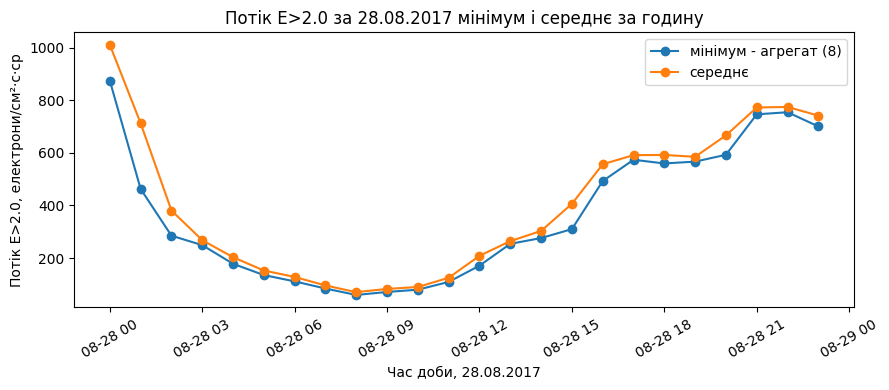

In [ ]:
# ВАШ КОД
доба = '2017-08-28'

потік_доби = A.set_index('ts').loc[доба, 'E>2.0'].resample('1h').agg(['min', 'mean'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(потік_доби.index, потік_доби['min'], marker='o', label='мінімум - агрегат (8)')
ax.plot(потік_доби.index, потік_доби['mean'], marker='o', label='середнє')

ax.set_xlabel('Час доби, 28.08.2017')
ax.set_ylabel('Потік E>2.0, електрони/см²·с·ср')
ax.set_title('Потік E>2.0 за 28.08.2017 мінімум і середнє за годину')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*
Мінімум завжди лежить нижче середнього — це очевидно за визначенням, але розмір розриву між ними змінюється залежно від того, наскільки рвані були 12 п'ятихвилинних вимірювань усередині години. Різниця стане суттєвою саме під час короткого, різкого спалаху сонячної активності: якщо потік підскочив на кілька хвилин і одразу впав, максимум і середнє це відобразять, а мінімум — ні, він продовжить показувати фонове значення.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [ ]:
# ВАШ КОД
M_inner = A.merge(C, on='ts', how='inner')

M_inner['дата'] = M_inner['ts'].dt.floor('D')
B['дата'] = B['ts'].dt.floor('D')

M_inner = M_inner.merge(B, on='дата', how='inner', suffixes=('', '_B'))

M_inner = M_inner.drop(
    columns=['дата', 'YR', 'MO', 'DA', 'HH', 'YR_B', 'MO_B', 'DA_B', 'ts_B'],
    errors='ignore'
)
M_inner = M_inner.sort_values('ts').reset_index(drop=True)

print('inner:', M_inner.shape)
M_inner[M_inner.isna().any(axis=1)]

inner: (600, 21)


,YR_x,MO_x,DA_x,HHMM,MJD,SOD,P>1,P>5,P>10,P>30,...,P>100,E>0.8,E>2.0,ts,YR_y,MO_y,DA_y,SPEED,DENSITY,F10.7
175,2017,9,4,700,58000,25200,6.58,0.242,0.204,0.1450,...,0.0523,100000.0,8950.0,2017-09-04 07:00:00,17,9,4,NaN,NaN,140
176,2017,9,4,800,58000,28800,4.29,0.207,0.169,0.1090,...,0.0257,79300.0,5850.0,2017-09-04 08:00:00,17,9,4,NaN,NaN,140
177,2017,9,4,900,58000,32400,4.40,0.518,0.258,0.1130,...,0.0765,62100.0,3680.0,2017-09-04 09:00:00,17,9,4,NaN,NaN,140
178,2017,9,4,1000,58000,36000,2.81,0.209,0.163,0.1020,...,0.0492,63300.0,4030.0,2017-09-04 10:00:00,17,9,4,NaN,NaN,140
179,2017,9,4,1100,58000,39600,3.69,0.204,0.167,0.0625,...,0.0257,67900.0,4790.0,2017-09-04 11:00:00,17,9,4,NaN,NaN,140
180,2017,9,4,1200,58000,43200,3.21,0.187,0.150,0.0910,...,0.0542,88700.0,7420.0,2017-09-04 12:00:00,17,9,4,NaN,NaN,140
181,2017,9,4,1300,58000,46800,3.82,0.300,0.129,0.0662,...,0.0294,75500.0,5500.0,2017-09-04 13:00:00,17,9,4,NaN,NaN,140
182,2017,9,4,1400,58000,50400,3.65,0.274,0.237,0.1780,...,0.0888,79300.0,7070.0,2017-09-04 14:00:00,17,9,4,NaN,NaN,140


In [ ]:
M_outer = A_hourly.merge(C, on='ts', how='outer')

M_outer['дата'] = M_outer['ts'].dt.floor('D')

M_outer = M_outer.merge(B, on='дата', how='outer', suffixes=('', '_B'))
M_outer = M_outer.drop(columns=['дата', 'YR', 'MO', 'DA', 'HH', 'YR_B', 'MO_B', 'DA_B', 'ts_B'], errors='ignore')
M_outer = M_outer.sort_values('ts').reset_index(drop=True)

print('outer:', M_outer.shape)
M = M_outer
M_outer[M_outer.isna().any(axis=1)]

outer: (601, 20)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,SPEED,DENSITY,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0
600,2017-09-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,381.0,1.0,NaN


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*Обираю outer. Спробував обидва типи об'єднання таблиці A_hourly і C по стовпцю ts, inner дав 600 рядків, outer — 601 рядок.
Причина розбіжності — таблиці закінчуються не в один і той самий момент, наприклад у таблиці C (сонячний вітер) є вимірювання за одну годину, якої немає в таблиці A (потоки частинок GOES-15).

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [ ]:
# ВАШ КОД
conditions = [
    M['P>10_max'] < 10,
    (M['P>10_max'] >= 10) & (M['P>10_max'] < 1000),
    M['P>10_max'] >= 1000
]
names = ['тиха', 'активна', 'дуже активна']

M['група'] = np.select(conditions, names, default='немає даних')

M['група'].value_counts()

,count
група,
тиха,411
активна,171
дуже активна,18
немає даних,1


**Самоперевірка етапу 4.**

In [ ]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

середнє: 11397.048492310607
медіана: 4338.75


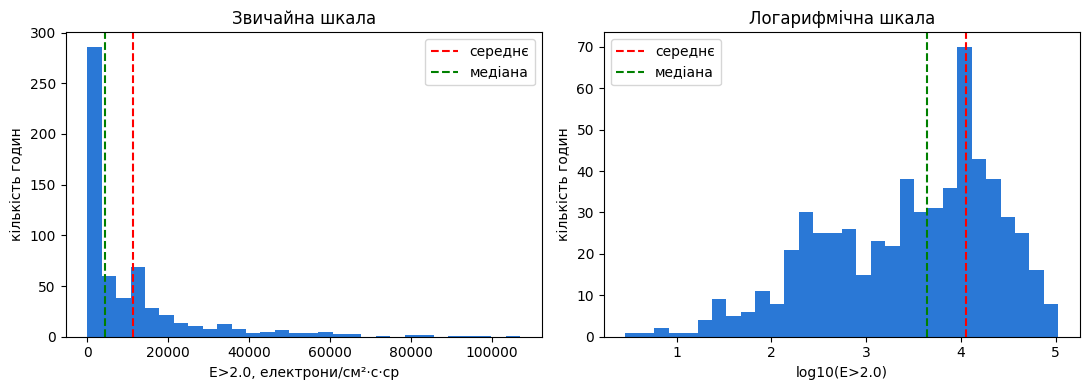

In [ ]:
# ВАШ КОД
flux_hourly = M['E>2.0_mean'].dropna()

mean_val = flux_hourly.mean()
median_val = flux_hourly.median()
print('середнє:', mean_val)
print('медіана:', median_val)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(flux_hourly, bins=30, color='#2a78d6')
ax[0].axvline(mean_val, color='red', linestyle='--', label='середнє')
ax[0].axvline(median_val, color='green', linestyle='--', label='медіана')
ax[0].set_xlabel('E>2.0, електрони/см²·с·ср')
ax[0].set_ylabel('кількість годин')
ax[0].set_title('Звичайна шкала')
ax[0].legend()

log_flux = np.log10(flux_hourly)
ax[1].hist(log_flux, bins=30, color='#2a78d6')
ax[1].axvline(np.log10(mean_val), color='red', linestyle='--', label='середнє')
ax[1].axvline(np.log10(median_val), color='green', linestyle='--', label='медіана')
ax[1].set_xlabel('log10(E>2.0)')
ax[1].set_ylabel('кількість годин')
ax[1].set_title('Логарифмічна шкала')
ax[1].legend()

fig.tight_layout()
plt.show()

**Висновок:**Середнє 11 397 майже у 2.6 рази більше за медіану 4 339. Звичайна гістограма ліворуч виглядає саме так, як сказано у завданні майже всі години зібрані в один стовпчик біля невеликих значень, а решта шкали — порожня, бо є кілька годин з дуже високими значеннями до 106 917, які "розтягують" вісь X, хоча самих таких годин мало.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

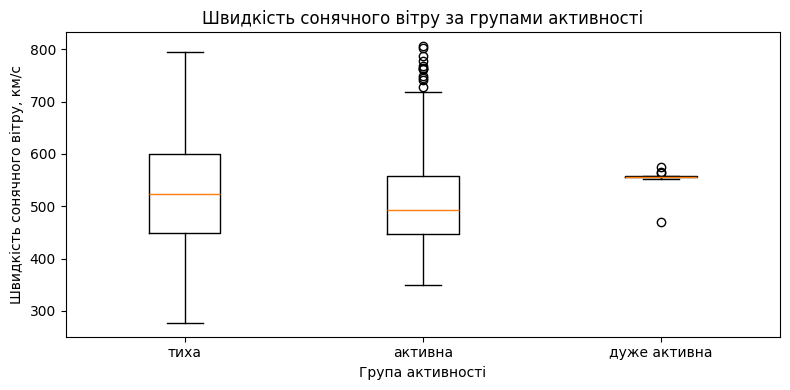

In [ ]:
# ВАШ КОД
group_order = ['тиха', 'активна', 'дуже активна']
speed_by_group = [M.loc[M['група'] == g, 'SPEED'].dropna() for g in group_order]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(speed_by_group, tick_labels=group_order)
ax.set_xlabel('Група активності')
ax.set_ylabel('Швидкість сонячного вітру, км/с')
ax.set_title('Швидкість сонячного вітру за групами активності')

plt.tight_layout()
plt.show()

**Висновок:**Медіанна швидкість вітру в "тихій" 524 км/с і "активній" 492 км/с групах практично не відрізняється, і лише в "дуже активній" групі, яка налічує всього 18 годин, вона трохи вища 556 км/с — надто мала різниця й надто мала вибірка, щоб говорити про справжній зв'язок між швидкістю вітру та рівнем потоку частинок.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

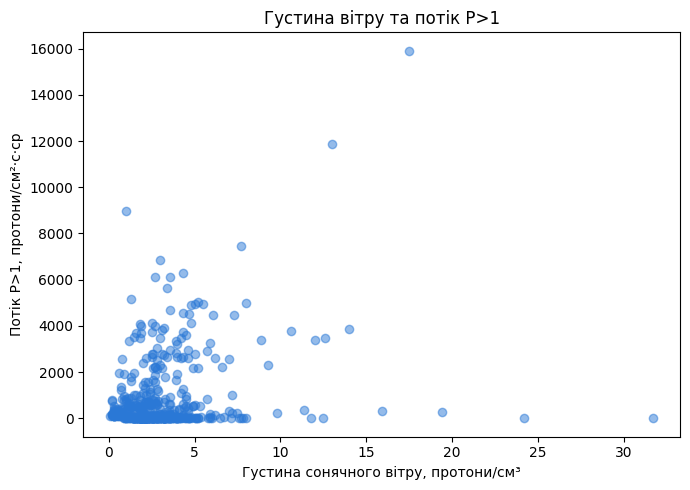

Коефіцієнт кореляції: 0.28528892999766575


In [ ]:
# ВАШ КОД
density = M['DENSITY']
flux_p1 = M['P>1_mean']

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(density, flux_p1, alpha=0.5, color='#2a78d6')
ax.set_xlabel('Густина сонячного вітру, протони/см³')
ax.set_ylabel('Потік P>1, протони/см²·с·ср')
ax.set_title('Густина вітру та потік P>1')

plt.tight_layout()
plt.show()

correlation = density.corr(flux_p1)
print('Коефіцієнт кореляції:', correlation)

**Висновок:**Коефіцієнт кореляції лише 0.29, і на діаграмі розсіювання точки утворюють широку "хмару" без чіткої лінійної залежності — помітного зв'язку між густиною вітру та потоком P>1 на цих даних немає.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

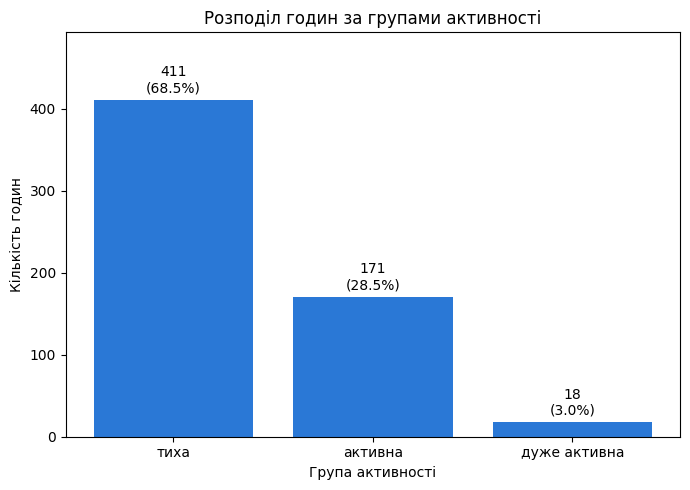

In [ ]:
# ВАШ КОД
group_order = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts().reindex(group_order)
total = counts.sum()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(group_order, counts, color='#2a78d6')

for bar, count in zip(bars, counts):
    pct = 100 * count / total
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             '%d\n(%.1f%%)' % (count, pct),
             ha='center', va='bottom')

ax.set_xlabel('Група активності')
ax.set_ylabel('Кількість годин')
ax.set_title('Розподіл годин за групами активності')
ax.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.show()

**Висновок:**Майже дві третини годин 68.5% — "тиха" активність, 28.5% — "активна", і лише 3.0% (18 годин) — "дуже активна".

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

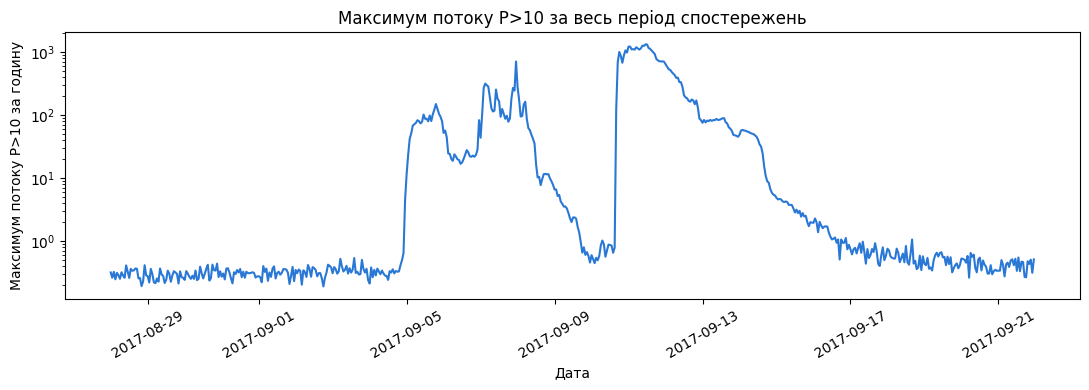

In [ ]:
# ВАШ КОД
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(M['ts'], M['P>10_max'], color='#2a78d6')
ax.set_yscale('log')
ax.set_xlabel('Дата')
ax.set_ylabel('Максимум потоку P>10 за годину')
ax.set_title('Максимум потоку P>10 за весь період спостережень')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Висновок:**Потік P>10 більшість часу тримається на низькому фоні (~0.3–0.5), але з 5 по 16 вересня спостерігається тривалий період підвищеної активності з двома підйомами, найпотужніший з яких тримався на плато приблизно 1000–1300 кілька діб підряд.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

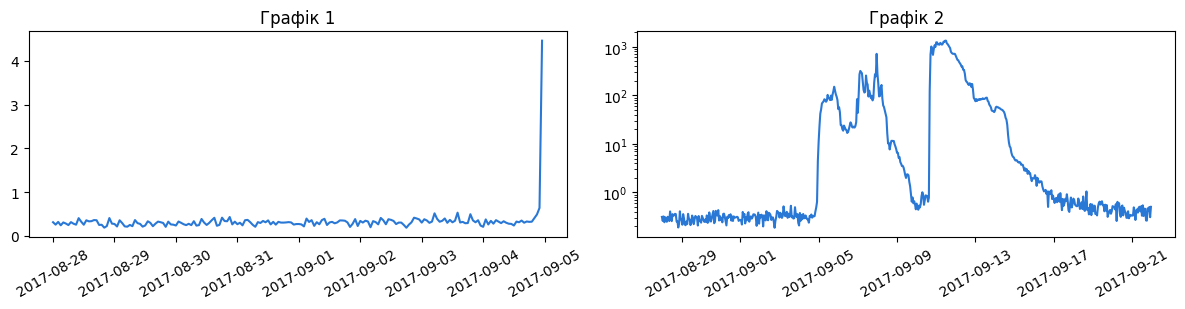

In [ ]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

window = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(window['ts'], window[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Скаже, що космічна погода 5 вересня різко збільшилася порівняно з останніми днями серпня. Вона бачить лише кілька днів спостереження тому те, що відбувалося згодом у вересні для неї буде загадкою
2. Висновок з другого графіка: Скаже, що космічна погода трималася у період з 5 по 16 вересня. Крім того вона зрозуміє що дана активність повторювалася двічі за не повний місяць
3. Дві відмінності між ними: Найголовніше - це часовий діапазон, на першому графіку видно лише кілька днів в той час як на другому - неповний місяць. Також відмінністю буде шкала градації, де на першому графіку зображено лінійну, а на іншому логарифмічну.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

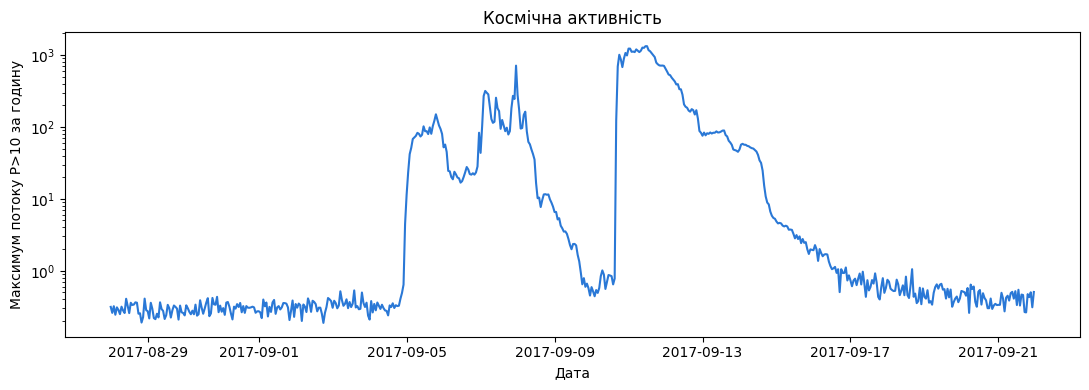

In [ ]:
# ВАШ КОД
СТОВПЕЦЬ = 'P>10_max'

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax.set_yscale('log')
ax.set_xlabel('Дата')
ax.set_ylabel('Максимум потоку P>10 за годину')
ax.set_title('Космічна активність')

plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)* Я побудував дуже схоже до другого графікв, але добавив також назву та підпис до кожної вісі, що покращує розуміння даних та що тут відбувається

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** В першу чергу помітив, що космічна активність тривала 2 тижні, з 5 по 16 вересня, причому вона спадала і знову підймалася. Це видно на графіку із завдання 6.2.

**Спостереження 2:** Логарифмічна шкала добре підходить коли дані розкидані на кілька порядків величин як у нашому випадку 10, 100, 1000 - це добре видно на нашому графіку 1.

**Спостереження 3:** Густина вітру та потік P>1 - дві величини, які ніяк не корелюють між собою це видно як за графіком 3 на 5 етапі, так і за величиною яку ми паралельно вивели 0.29


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [ ]:
# ВАШ КОД
rows_with_na = M.isna().any(axis=1).sum()
total = len(M)

print('Рядків з пропуском:', rows_with_na)
print('Усього рядків:', total)
print('Частка:', rows_with_na / total)

Рядків з пропуском: 9
Усього рядків: 601
Частка: 0.014975041597337771


**Відповідь 7.2:**Використавши outer join отримав об'єднану табличку розміром (601, 20). Оскільки в нас першочергово були пропуски в даних у таблиці С, значення -1, які ми потім поміняли на NaN то вони перейшли в об'єднану табличку M. Ну і ще одне значення береться з таблички А, при об'єднанні воно не знайшло пару.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [ ]:
ІНСТРУМЕНТИ_ШІ = 'Claude AI'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Перевіряв висновки, які згенерував штучний інтелект та поправляв на власний лад. В одному випадку він почав англійською мовою писати назву колонок у датафреймі, тому вичитка не спрацьовувала й довелося виправляти.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Фарина Арсеній
інструменти:                                   Claude AI
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Перевіряв висновки, які згенерував штучний інтелект та поправляв на власний лад. В одному випадку він почав англійською мовою писати назву колонок у датафреймі, тому вичитка не спрацьовувала й довелося виправляти.
Автор підтверджує, що може пояснити кожен рядок коду під час захис

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [ ]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [ ]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
